In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


c:\Users\hetpe\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
data_dir = './data'
data_output_dir = './data/output'

In [3]:
data_casy = pd.read_csv(f'{data_dir}/Casy.csv', index_col=False)
data_casy.head()



,sample_type,channel,replicate,mean_diameter,peak_diameter,sample_dilution,measurement_name,sample_volume,casyton_volume,measurement_volume,counts
0,ABB,4,1,2.0477,1.519,2,13,10,10000,200,2212
1,ABB,4,2,2.0490,1.460,2,13,10,10000,200,2292
2,ABB,4,3,2.0726,1.616,2,13,10,10000,200,2407
3,ABB,5,1,2.1146,1.479,2,6,10,10000,200,570
4,ABB,5,2,2.0694,1.577,2,6,10,10000,200,625


In [4]:
data_casy.info()


<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sample_type         54 non-null     str    
 1   channel             54 non-null     int64  
 2   replicate           54 non-null     int64  
 3   mean_diameter       54 non-null     float64
 4   peak_diameter       54 non-null     float64
 5   sample_dilution     54 non-null     int64  
 6   measurement_name    54 non-null     int64  
 7   sample_volume       54 non-null     int64  
 8   casyton_volume      54 non-null     int64  
 9   measurement_volume  54 non-null     int64  
 10  counts              54 non-null     int64  
dtypes: float64(2), int64(8), str(1)
memory usage: 4.9 KB


In [5]:
data_casy['channel'].unique()

array([4, 5, 7, 3, 8, 1])

In [6]:
### Data structure:
# sample_type: to identify whether it is MC, BBB, or ABB
# channel: one culture. Within each channel, 
#  - array([4, 5, 7, 3, 8, 1])
#  - there are 3 sample types (MC, BBB, ABB) 
#  - 3 replicates of each sample type. So there are 9 samples in total for each channel.
# measurement_name: unique to each sample_type and measurement, but NOT unique to replicates of the same sample_type and measurement
# sample_type: to identify whether it is MC, BBB, or ABB
# replicate: for the 3 runs of the same sample
#
# MC = Multi-Cultivator sample, not used for ploidy determination
# BBB = before bead-beating
# ABB = after bead-beating

In [7]:
# sample_id format: ch{channel}_{sample_type}_{measurement_name}
# sample_rep_id format: {sample_id}_r{replicate}
data_casy['sample_id'] = (
    'ch' + data_casy['channel'].astype(str)
    + '_' + data_casy['sample_type'].astype(str)
    + '_' + data_casy['measurement_name'].astype(str)
)
data_casy['sample_rep_id'] = (
    data_casy['sample_id']
    + '_r' + data_casy['replicate'].astype(str)
)

cols = data_casy.columns.tolist()
cols = ['sample_id', 'sample_rep_id'] + [col for col in cols if col not in ['sample_id', 'sample_rep_id']]
data_casy = data_casy[cols]
data_casy.head()

,sample_id,sample_rep_id,sample_type,channel,replicate,mean_diameter,peak_diameter,sample_dilution,measurement_name,sample_volume,casyton_volume,measurement_volume,counts
0,ch4_ABB_13,ch4_ABB_13_r1,ABB,4,1,2.0477,1.519,2,13,10,10000,200,2212
1,ch4_ABB_13,ch4_ABB_13_r2,ABB,4,2,2.0490,1.460,2,13,10,10000,200,2292
2,ch4_ABB_13,ch4_ABB_13_r3,ABB,4,3,2.0726,1.616,2,13,10,10000,200,2407
3,ch5_ABB_6,ch5_ABB_6_r1,ABB,5,1,2.1146,1.479,2,6,10,10000,200,570
4,ch5_ABB_6,ch5_ABB_6_r2,ABB,5,2,2.0694,1.577,2,6,10,10000,200,625


In [8]:
### Casy Counter
# Protocol
# 1. Dilute sample of interest (measurement range)
# 2. Pipette 10 μL dilution into CASY-vial with 10 mL of CASY-ton buffer
# 3. Insert CASY-vial into CASY-counter
# 4. Measure:
#     - CASY-counter will perform 3 measurements of each sample
#     - Each measurement will take 200 μL from CASY-vial
#     - The machine will report for each measurement:
#         - Total number of counts
#         - Peak diameter
#         - Average diameter
#
# So, this means that:
# - 10 μL of diluted sample
# - into 10000 μL of CASY-ton buffer
#
# example calculation:
# measurement_volume = 200μL
# counts = 2212
# sample_volume = 10 μL  e.
# casyton_volume = 10000 μL
# sample_dilution = 2    e.g. sample is diluted to 1:2 with casyton volumee
#
# Formula:
# cells / μL = (counts / measurement_volume) * ((sample_volume + casyton_volume) / sample_volume) * sample_dilution
#
# Example:
# cells / μL = (2212 / 200) * ((10 + 10000) / 10) * 2
# cells / μL = 11.06 * 1001 * 2
# cells / μL = 22142.12
#
# cells / mL = cells / μL * 1000
# cells / mL = 22142.12 * 1000
# cells / mL = 22142120


data_casy['counts_per_ul_casy_vial'] = data_casy['counts'] / data_casy["measurement_volume"] 

data_casy['counts_per_ul_diluted_sample'] = data_casy['counts_per_ul_casy_vial'] * ((data_casy['sample_volume'] + data_casy['casyton_volume']) / data_casy['sample_volume'])

data_casy['counts_per_ul_original_sample'] = data_casy['counts_per_ul_diluted_sample'] * data_casy['sample_dilution']

data_casy['counts_per_ml_original_sample'] = data_casy['counts_per_ul_original_sample'] * 1000

data_casy.head()


,sample_id,sample_rep_id,sample_type,channel,replicate,mean_diameter,peak_diameter,sample_dilution,measurement_name,sample_volume,casyton_volume,measurement_volume,counts,counts_per_ul_casy_vial,counts_per_ul_diluted_sample,counts_per_ul_original_sample,counts_per_ml_original_sample
0,ch4_ABB_13,ch4_ABB_13_r1,ABB,4,1,2.0477,1.519,2,13,10,10000,200,2212,11.060,11071.060,22142.12,22142120.0
1,ch4_ABB_13,ch4_ABB_13_r2,ABB,4,2,2.0490,1.460,2,13,10,10000,200,2292,11.460,11471.460,22942.92,22942920.0
2,ch4_ABB_13,ch4_ABB_13_r3,ABB,4,3,2.0726,1.616,2,13,10,10000,200,2407,12.035,12047.035,24094.07,24094070.0
3,ch5_ABB_6,ch5_ABB_6_r1,ABB,5,1,2.1146,1.479,2,6,10,10000,200,570,2.850,2852.850,5705.70,5705700.0
4,ch5_ABB_6,ch5_ABB_6_r2,ABB,5,2,2.0694,1.577,2,6,10,10000,200,625,3.125,3128.125,6256.25,6256250.0


In [ ]:
data_casy.to_csv(f'{data_output_dir}/Casy_counts_processed.csv', index=False)

In [9]:
data_casy_counts = data_casy.drop(columns=['sample_dilution', 'measurement_name', 'sample_volume', 'casyton_volume', 'measurement_volume'])
data_casy_counts.head()

,sample_id,sample_rep_id,sample_type,channel,replicate,mean_diameter,peak_diameter,counts,counts_per_ul_casy_vial,counts_per_ul_diluted_sample,counts_per_ul_original_sample,counts_per_ml_original_sample
0,ch4_ABB_13,ch4_ABB_13_r1,ABB,4,1,2.0477,1.519,2212,11.060,11071.060,22142.12,22142120.0
1,ch4_ABB_13,ch4_ABB_13_r2,ABB,4,2,2.0490,1.460,2292,11.460,11471.460,22942.92,22942920.0
2,ch4_ABB_13,ch4_ABB_13_r3,ABB,4,3,2.0726,1.616,2407,12.035,12047.035,24094.07,24094070.0
3,ch5_ABB_6,ch5_ABB_6_r1,ABB,5,1,2.1146,1.479,570,2.850,2852.850,5705.70,5705700.0
4,ch5_ABB_6,ch5_ABB_6_r2,ABB,5,2,2.0694,1.577,625,3.125,3128.125,6256.25,6256250.0


In [10]:
# average across replicate measurements for each sample_id
# reduce data to one value per channel + sample_type by avg of replicates

data_casy_avg = (
    data_casy
    .groupby(['channel', 'sample_type'], as_index=False)
    .agg(
        mean_cells_per_ml=('counts_per_ml_original_sample', 'mean'),
        sd_cells_per_ml=('counts_per_ml_original_sample', 'std'),
        n_replicates=('counts_per_ml_original_sample', 'size')
    )
)

data_casy_avg = data_casy_avg.sort_values(by='channel').reset_index(drop=True)
data_casy_avg['sample_id'] = 'ch' + data_casy_avg['channel'].astype(str) + '_' + data_casy_avg['sample_type']
data_casy_avg.head()

,channel,sample_type,mean_cells_per_ml,sd_cells_per_ml,n_replicates,sample_id
0,1,ABB,6.639633e+07,7.159775e+05,3,ch1_ABB
1,1,BBB,2.303134e+08,8.148831e+06,3,ch1_BBB
2,1,MC,2.258256e+07,4.057756e+05,3,ch1_MC
3,3,ABB,1.313646e+07,1.332997e+05,3,ch3_ABB
4,3,BBB,2.586751e+08,6.632018e+06,3,ch3_BBB


In [ ]:
data_casy_avg.to_csv(f'{data_output_dir}/Casy_counts_avg.csv', index=False)

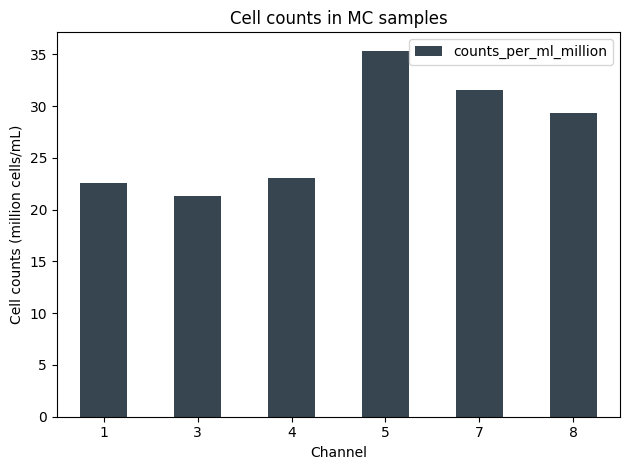

In [11]:
# Cell counts in MC samples (millions of cells per mL)
mc_counts = data_casy_avg[
    data_casy_avg['sample_type'].str.lower() == 'mc'
].copy()
mc_counts['counts_per_ml_million'] = mc_counts['mean_cells_per_ml'] / 1_000_000
mc_counts = mc_counts.sort_values('channel')

mc_counts.plot(x='channel', y='counts_per_ml_million', kind='bar', color='#36454F')
plt.ylabel('Cell counts (million cells/mL)')
plt.xlabel('Channel')
plt.title('Cell counts in MC samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("cell_counts_mc_sample.pdf")
plt.show()

In [ ]:
mc_counts.to_csv(f'{data_output_dir}/casy_mc_counts.csv', index=False)

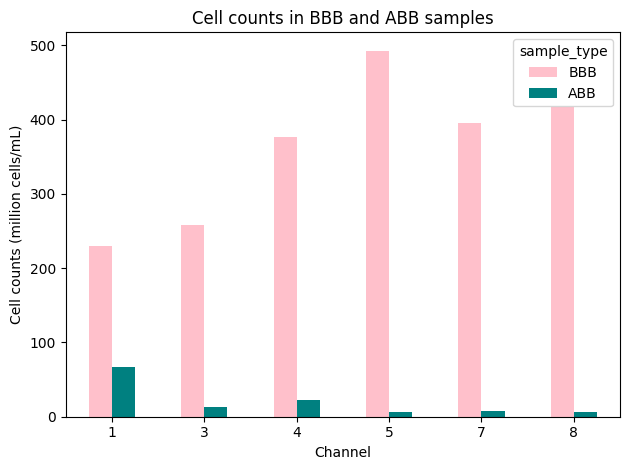

In [12]:
# cell counts in BBB and ABB samples (millions of cells / mL)
# grouped by channel and sample type (BBB vs ABB)
bbb_abb_counts = data_casy_avg[
    data_casy_avg['sample_type'].str.lower().isin(['bbb', 'abb'])
].copy()
bbb_abb_counts['counts_per_ml_million'] = bbb_abb_counts['mean_cells_per_ml'] / 1_000_000

plot_df = (
    bbb_abb_counts.assign(sample_type=bbb_abb_counts['sample_type'].str.upper())
    .pivot(index='channel', columns='sample_type', values='counts_per_ml_million')
    .reindex(columns=['BBB', 'ABB'])
    .sort_index()
)

plot_df.plot(kind='bar', color=['pink', 'teal'])
plt.ylabel('Cell counts (million cells/mL)')
plt.xlabel('Channel')
plt.title('Cell counts in BBB and ABB samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("cell_counts_bbbandabb_sample.pdf")
plt.show()

In [ ]:
bbb_abb_counts.to_csv(f'{data_output_dir}/casy_bbb_abb_counts.csv', index=False)

In [13]:
data_casy_ploidy = data_casy_avg[data_casy_avg['sample_type'].isin(['BBB', 'ABB'])].copy()

data_casy_wide = (
    data_casy_ploidy
    .pivot(index='channel', columns='sample_type', values='mean_cells_per_ml')
    .reset_index()
)

data_casy_wide['broken_cells_per_ml'] = data_casy_wide['BBB'] - data_casy_wide['ABB']


data_casy_wide['lysis_efficiency_pct'] = (
    data_casy_wide['broken_cells_per_ml'] / data_casy_wide['BBB'] * 100
)

data_casy_wide.head()

sample_type,channel,ABB,BBB,broken_cells_per_ml,lysis_efficiency_pct
0,1,6.639633e+07,2.303134e+08,1.639171e+08,71.171315
1,3,1.313646e+07,2.586751e+08,2.455386e+08,94.921638
2,4,2.305970e+07,3.762926e+08,3.532329e+08,93.871869
3,5,6.286280e+06,4.930759e+08,4.867896e+08,98.725089
4,7,8.014673e+06,3.951448e+08,3.871301e+08,97.971712


In [ ]:
data_casy_wide.to_csv(f'{data_output_dir}/casy_ploidy_calculations.csv', index=False)

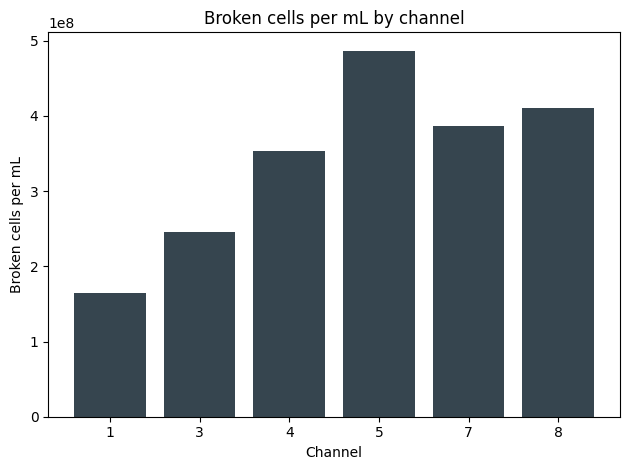

In [14]:
plt.bar(
    data_casy_wide['channel'].astype(str),
    data_casy_wide['broken_cells_per_ml'],
    color='#36454F'
    
)
plt.xlabel('Channel')
plt.ylabel('Broken cells per mL')
plt.title('Broken cells per mL by channel')

plt.tight_layout()
plt.savefig("broken_cells.pdf")
plt.show()

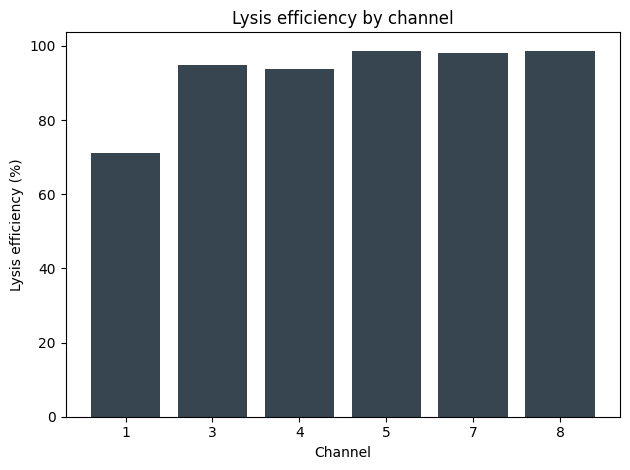

In [15]:
plt.bar(
    data_casy_wide['channel'].astype(str),
    data_casy_wide['lysis_efficiency_pct'],
    color='#36454F'
)
plt.xlabel('Channel')
plt.ylabel('Lysis efficiency (%)')
plt.title('Lysis efficiency by channel')
plt.tight_layout()
plt.savefig("lysis_eff.pdf")
plt.show()

In [16]:
### qPCR determination steps
# 96-well plate 
# To each well aded:
# - 15 μL master-mix (primers, polymerase, SYBR-green, mQH2O)
# - 5 μL (diluted) cell extract or standard
#
# qPCR Standard curve:
# 3 independent serial dilutions 
# 7 points, diluting the solution 10 times in each step
# initial [DNA] = 0.04 ng DNA / μL
#
# Steps to make standard curve:
# 1. Calculate [DNA] in each standard dilution -> use dilution_factor column
# 2. Find the concentration in well (15 μL + 5 μL)
# 3. Fit linear regression model to Ct ~ log10([DNA])
# 
# From ng to # of molecules:
# 
# Ignoring the unit conversion for now the formula is:
# dna_molecules_in_well = (dna_conc_standard / dilution_factor) * (sample_volume_in_well / total_volume_in_well) / dna_fragment_molecular_weight * avogadro_number 
#
# where:
#   dna_conc_standard = 0.04 ng/μL.  # initial concentration of DNA in the standard solution
#   dilution_factor = 10 ** standard_point  # dilution factor for each standard point
#   sample_volume_in_well = 5 μL  # volume of diluted DNA solution added to the well
#   total_volume_in_well = 20 μL  # total volume in the well (5 μL diluted DNA + 15 μL master mix)
#   dna_fragment_molecular_weight = sequence_length * average_weight_per_base_pair  # weight of the DNA fragment in ng
#   avogadro_number = 6.022e23  # number of molecules per mole
#   dna_conc_diluted = dna_conc_standard / dilution_factor  # concentration of DNA in the diluted standard solution


In [17]:
# qPCR cycle threshold (Ct) values are inversely proportional to the amount of target nucleic acid in the sample. 
# A lower Ct value indicates a higher amount of target nucleic acid, 
# while a higher Ct value indicates a lower amount of target nucleic acid. 
# This is because it takes fewer cycles for the fluorescence signal to reach 
# the threshold when there is more target nucleic acid present in the sample.

data_qpcr = pd.read_csv(f'{data_dir}/qPCR.csv', index_col=False)
data_qpcr.head()

# order by sample and time
data_qpcr = data_qpcr.sort_values(by=['sample_id'])
data_qpcr.head()

#Ct change per sample

,sample_id,channel,replicate,dilution_replicate,Ct,dilution_factor,sample_class,template_vol,final_vol
0,200206_0_4,4.0,1,1.0,15,10,sample,5,20
6,200206_0_4,4.0,1,2.0,18,100,sample,5,20
12,200206_0_4,4.0,1,3.0,21,1000,sample,5,20
18,200206_0_4,4.0,2,1.0,15,10,sample,5,20
24,200206_0_4,4.0,2,2.0,18,100,sample,5,20


In [18]:
# standard_point 1..7 = S1..S7
# dilution_factor = 10 * standard_point starting at 10
# 
# S1 dilution_factor = 10^1 = 10
# ...
# S6 dilution_factor = 10^6 = 1000000
# S7 dilution_factor = 10^7 = 10000000
#
# replicate 1..3 = each standard point is measured 3 times

In [19]:
### From ng to # of molecules

# Checked it manully and its 1085
with open(f'{data_dir}/standard_fragment_sequence.txt', 'r') as f:
    fragment_content = f.read().strip()
length_bp = len(fragment_content) # 1085

# REF: Ploidy in Cynabacteria (2011), Griesen et al. 
# under spectrocopic method for ploidy determination
weight_bp = 660 # g/mol per base pair

molecular_weight_g_per_mol = length_bp * weight_bp
print(f'Molecular weight: {molecular_weight_g_per_mol} g/mol')

Molecular weight: 716100 g/mol


In [20]:
dna_conc_standard_ng_per_ul = 0.04 
sample_volume_in_well_ul = 5
total_volume_in_well_ul = 20
avogadro_number = 6.022e23
weight_bp_g_per_mol = 660  # g/mol per bp for dsDNA
length_bp = 1085  # length of the DNA fragment in base pairs
molecular_weight_g_per_mol = length_bp * weight_bp_g_per_mol

qpcr = data_qpcr.copy()

qpcr_standard = qpcr.loc[qpcr['sample_class'].eq('standard')].copy()

# S1 -> 1, ..., S7 -> 7
qpcr_standard['standard_point'] = (
    qpcr_standard['sample_id'].astype(str).str.extract(r'(\d+)')[0].astype(int)
)

# REF: 
# dna_molecules_in_well = (dna_conc_standard / dilution_factor) * (sample_volume_in_well / total_volume_in_well) / dna_fragment_molecular_weight * avogadro_number 
qpcr_standard['dna_conc_diluted_ng_per_ul'] =  dna_conc_standard_ng_per_ul / qpcr_standard['dilution_factor']


qpcr_standard['dna_conc_in_well_ng_per_ul'] = qpcr_standard['dna_conc_diluted_ng_per_ul'] * (sample_volume_in_well_ul / total_volume_in_well_ul)

# 1e-9  => ng -> g
qpcr_standard['dna_molecules_in_well_per_ul'] = qpcr_standard['dna_conc_in_well_ng_per_ul'] * 1e-9 / molecular_weight_g_per_mol * avogadro_number

qpcr_standard['log10_dna_molecules_in_well_per_ul'] = np.log10(qpcr_standard['dna_molecules_in_well_per_ul'])

qpcr_standard[
    [
        'sample_id', 'standard_point', 'replicate', 'dilution_factor', 'Ct',
        'dna_conc_diluted_ng_per_ul', 'dna_conc_in_well_ng_per_ul',
        'dna_molecules_in_well_per_ul', 'log10_dna_molecules_in_well_per_ul'
    ]
].sort_values(['standard_point', 'replicate'])


,sample_id,standard_point,replicate,dilution_factor,Ct,dna_conc_diluted_ng_per_ul,dna_conc_in_well_ng_per_ul,dna_molecules_in_well_per_ul,log10_dna_molecules_in_well_per_ul
36,S1,1,1,10,9,4.000000e-03,1.000000e-03,840944.002234,5.924767
43,S1,1,2,10,9,4.000000e-03,1.000000e-03,840944.002234,5.924767
50,S1,1,3,10,9,4.000000e-03,1.000000e-03,840944.002234,5.924767
37,S2,2,1,100,12,4.000000e-04,1.000000e-04,84094.400223,4.924767
44,S2,2,2,100,12,4.000000e-04,1.000000e-04,84094.400223,4.924767
51,S2,2,3,100,12,4.000000e-04,1.000000e-04,84094.400223,4.924767
38,S3,3,1,1000,15,4.000000e-05,1.000000e-05,8409.440022,3.924767
45,S3,3,2,1000,15,4.000000e-05,1.000000e-05,8409.440022,3.924767
52,S3,3,3,1000,15,4.000000e-05,1.000000e-05,8409.440022,3.924767
39,S4,4,1,10000,18,4.000000e-06,1.000000e-06,840.944002,2.924767


In [21]:
# save processed data
qpcr_standard.to_csv(f'{data_output_dir}/qpcr_standard_output.csv', index=False)

In [22]:

### Amplification efficiency calculation
# (E - 1) * 100
# E = 10^(-1/slope)
# Ideally, fluorescence doubles every cycle (E = 2)
# ideal slope is -3.32 (E = 10^(-1/-3.32) = 2)

def fit_standard_curve(df):
    x = df['log10_dna_molecules_in_well_per_ul'].to_numpy()
    y = df['Ct'].to_numpy()

    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept

    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    efficiency = 10 ** (-1 / slope) # E = 10^(-1/slope)
    efficiency_pct = (efficiency - 1) * 100 # (E - 1) * 100

    return pd.Series({
        'slope': slope,
        'intercept': intercept,
        'r2': r2,
        'efficiency': efficiency,
        'efficiency_pct': efficiency_pct
    })

In [23]:
### EAch replicate separately
curve_stats = (
    qpcr_standard
    .groupby('replicate')
    .apply(fit_standard_curve, include_groups=False)
    .reset_index()
)

### all curve
all_stats = fit_standard_curve(qpcr_standard).to_frame().T
all_stats['replicate'] = 'all'

curve_stats = pd.concat([curve_stats, all_stats], ignore_index=True)


curve_stats.to_csv(f'{data_output_dir}/standard_curve_stats.csv', index=False)

curve_stats


,replicate,slope,intercept,r2,efficiency,efficiency_pct
0,1,-3.321429,28.285834,0.997348,2.000209,100.020850
1,2,-3.214286,27.972466,0.998521,2.046968,104.696827
2,3,-3.000000,26.774301,1.000000,2.154435,115.443469
3,all,-3.178571,27.677533,0.994989,2.063511,106.351078


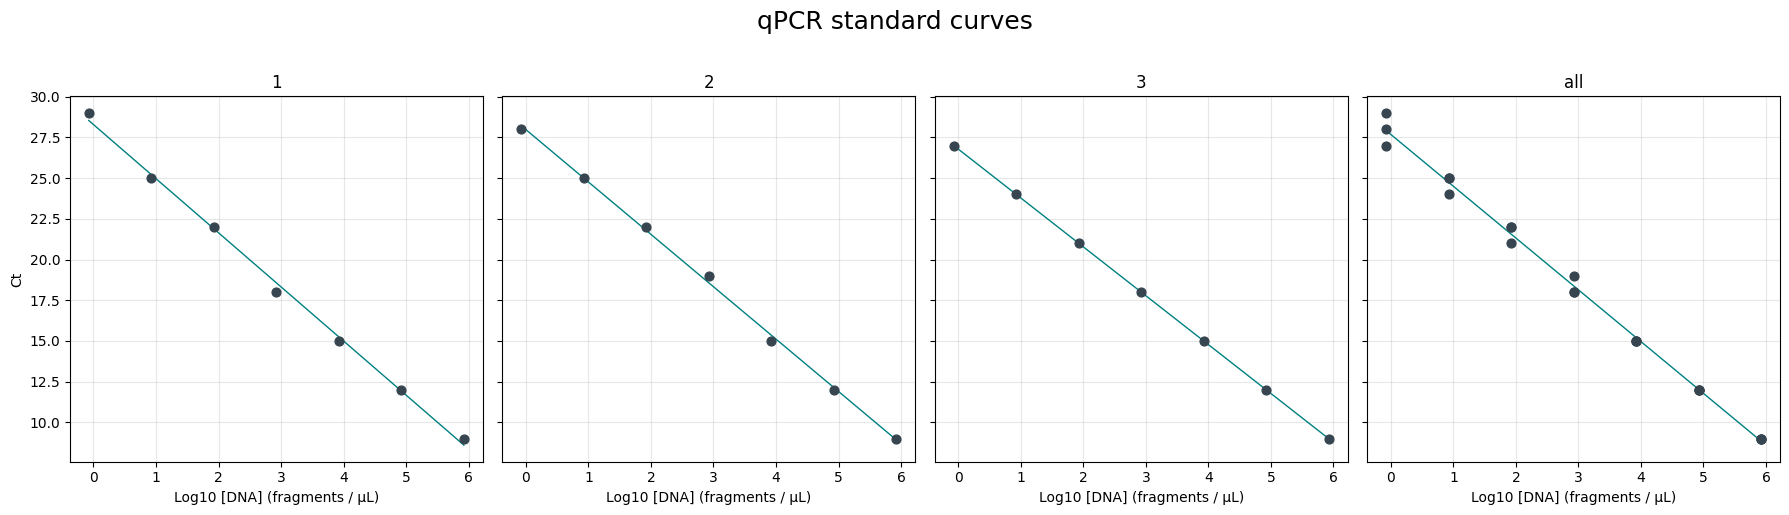

In [24]:
### Plotting standard curves for each replicate and all together
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

top_labels = [1, 2, 3, 'all']

for ax, rep in zip(axes, top_labels):
    if rep == 'all':
        df_plot = qpcr_standard.copy()
        stats_row = curve_stats[curve_stats['replicate'] == 'all'].iloc[0]
    else:
        df_plot = qpcr_standard[qpcr_standard['replicate'] == rep].copy()
        stats_row = curve_stats[curve_stats['replicate'] == rep].iloc[0]

    x = df_plot['log10_dna_molecules_in_well_per_ul'].to_numpy()
    y = df_plot['Ct'].to_numpy()

    ax.scatter(x, y, color='#36454F', s=40, zorder=3)

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = stats_row['slope'] * x_line + stats_row['intercept']
    ax.plot(x_line, y_line, color='teal', linewidth=1)

    ax.set_title(str(rep))
    ax.set_xlabel('Log10 [DNA] (fragments / μL)')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Ct')

fig.suptitle('qPCR standard curves', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("qpcr_stn_curves.pdf")
plt.show()

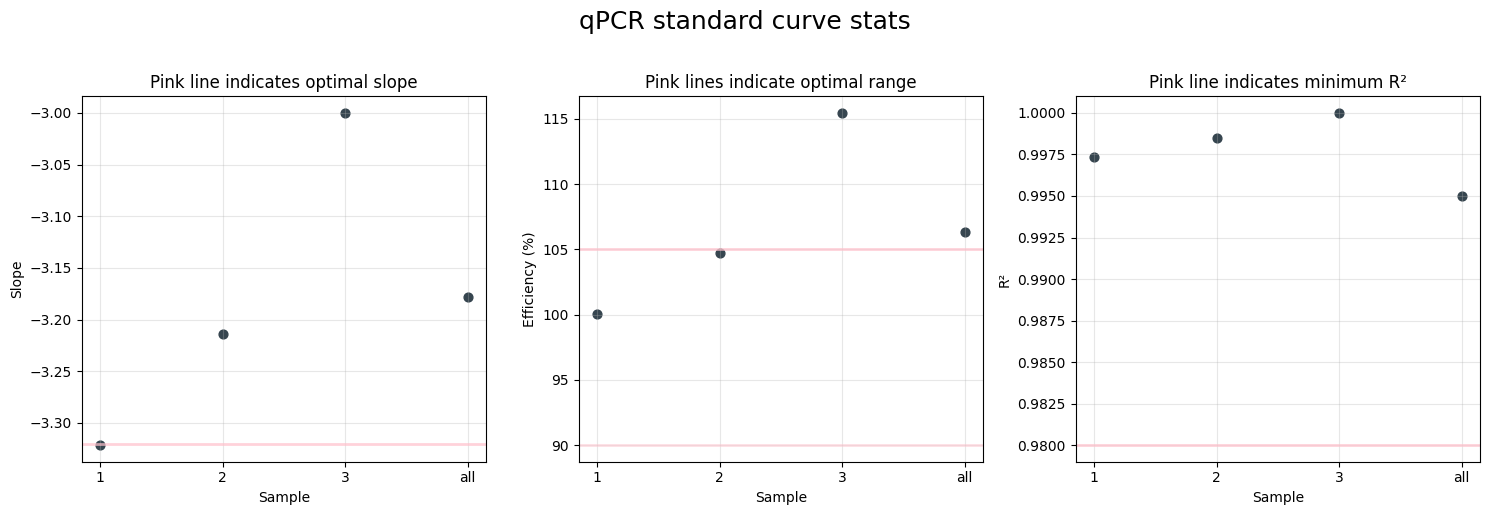

In [25]:
### Summary plots for slope, efficiency, R2 across replicates and all
curve_stats_plot = curve_stats.copy()

curve_stats_plot['replicate_str'] = curve_stats_plot['replicate'].astype(str)
curve_stats_plot['replicate_str'] = pd.Categorical(
    curve_stats_plot['replicate_str'],
    categories=['1', '2', '3', 'all'],
    ordered=True
)
curve_stats_plot = curve_stats_plot.sort_values('replicate_str')

x_labels = curve_stats_plot['replicate_str'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# slope
axes[0].scatter(x_labels, curve_stats_plot['slope'], color='#36454F', s=40)
axes[0].axhline(-3.32, color='pink', linewidth=2, alpha=0.7)
axes[0].set_title('Pink line indicates optimal slope')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Slope')
axes[0].grid(True, alpha=0.3)

# efficiency
axes[1].scatter(x_labels, curve_stats_plot['efficiency_pct'], color='#36454F', s=40)
axes[1].axhline(90, color='pink', linewidth=2, alpha=0.5)
axes[1].axhline(105, color='pink', linewidth=2, alpha=0.7)
axes[1].set_title('Pink lines indicate optimal range')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Efficiency (%)')
axes[1].grid(True, alpha=0.3)

# R2
axes[2].scatter(x_labels, curve_stats_plot['r2'], color='#36454F', s=40)
axes[2].axhline(0.98, color='pink', linewidth=2, alpha=0.7)
axes[2].set_title('Pink line indicates minimum R²')
axes[2].set_xlabel('Sample')
axes[2].set_ylabel('R²')
axes[2].grid(True, alpha=0.3)

fig.suptitle('qPCR standard curve stats', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("qpcr_stats.pdf")
plt.show()

In [26]:
curve_stats

,replicate,slope,intercept,r2,efficiency,efficiency_pct
0,1,-3.321429,28.285834,0.997348,2.000209,100.020850
1,2,-3.214286,27.972466,0.998521,2.046968,104.696827
2,3,-3.000000,26.774301,1.000000,2.154435,115.443469
3,all,-3.178571,27.677533,0.994989,2.063511,106.351078


In [27]:
### Ideal slope
# 
# (E - 1) * 100
# E = 10^(-1/slope)
# Ideally, fluorescence doubles every cycle (E = 2)
# ideal slope is -3.32 (E = 10^(-1/-3.32) = 2)
#
# Replicate 1 is the best, with slope, efficiency, and R2 all within the optimal range.
#   Slope: -3.3214 close to the ideal slope
#   Efficiency: 100.02% between the optimal range of 90-105%
#   R2: 0.9973 strong and above the minimum threshold of 0.98

In [28]:
# From replicate 1
best_slope = -3.3214
best_efficiency_pct = 100.02
best_r2 = 0.9973

In [29]:
### Calculate the # DNA fragments / μL in the cell extracts:
# ct = slope * log10(dna_molecules_in_well_per_ul) + intercept
# [DNA] in well = 10^((ct - intercept) / slope)
#
# where:
#   ct = cycle threshold value from qPCR for the sample
#   slope = slope from the best standard curve
#   intercept = intercept from the best standard curve
#
### Find the concentration in sample (15 μL master mix + 5 μL sample)
# 
# Given each well contains:
#   15 μL master-mix
#   5 μL (diluted) cell extract or standard
# 
# [DNA] in sample = [DNA] in well * (total_volume_in_well / sample_volume_in_well)
#
# where:
#   total_volume_in_well = 20 μL (5 μL sample + 15 μL master mix)
#   sample_volume_in_well = 5 μL
#
### Correct for dilution factor in sample
# [DNA] in original sample = [DNA] in sample * dilution_factor
# 
# where:
#   dna_conc_standard = 0.04 ng/μL.  # initial concentration of DNA in the standard solution
#   dilution_factor = dilution factor for each sample row

In [30]:
best_slope = -3.3214285714285703
best_intercept = 28.28583350724572

qpcr_sample = qpcr.loc[qpcr['sample_class'].eq('sample')].copy()

### DNA fragments / μL in the qPCR well
qpcr_sample['log10_dna_fragments_in_well_per_ul'] = (qpcr_sample['Ct'] - best_intercept) / best_slope


qpcr_sample['dna_fragments_in_well_per_ul'] = 10 ** qpcr_sample['log10_dna_fragments_in_well_per_ul']


qpcr_sample['dna_fragments_in_diluted_extract_per_ul'] = qpcr_sample['dna_fragments_in_well_per_ul'] * (20 / 5)

qpcr_sample['dna_fragments_in_original_extract_per_ul'] = qpcr_sample['dna_fragments_in_diluted_extract_per_ul'] * qpcr_sample['dilution_factor']

qpcr_sample[
    [
        'sample_id', 'channel', 'replicate', 'dilution_factor', 'Ct',
        'dna_fragments_in_well_per_ul',
        'dna_fragments_in_diluted_extract_per_ul',
        'dna_fragments_in_original_extract_per_ul'
    ]
].sort_values(['channel', 'replicate', 'dilution_factor'])

qpcr_sample.to_csv(f'{data_output_dir}/qpcr_sample_dna_conc_output.csv', index=False)

qpcr_sample.head()

,sample_id,channel,replicate,dilution_replicate,Ct,dilution_factor,sample_class,template_vol,final_vol,log10_dna_fragments_in_well_per_ul,dna_fragments_in_well_per_ul,dna_fragments_in_diluted_extract_per_ul,dna_fragments_in_original_extract_per_ul
0,200206_0_4,4.0,1,1.0,15,10,sample,5,20,4.000036,10000.826539,40003.306156,400033.061565
6,200206_0_4,4.0,1,2.0,18,100,sample,5,20,3.096810,1249.712426,4998.849706,499884.970551
12,200206_0_4,4.0,1,3.0,21,1000,sample,5,20,2.193584,156.165207,624.660829,624660.828794
18,200206_0_4,4.0,2,1.0,15,10,sample,5,20,4.000036,10000.826539,40003.306156,400033.061565
24,200206_0_4,4.0,2,2.0,18,100,sample,5,20,3.096810,1249.712426,4998.849706,499884.970551


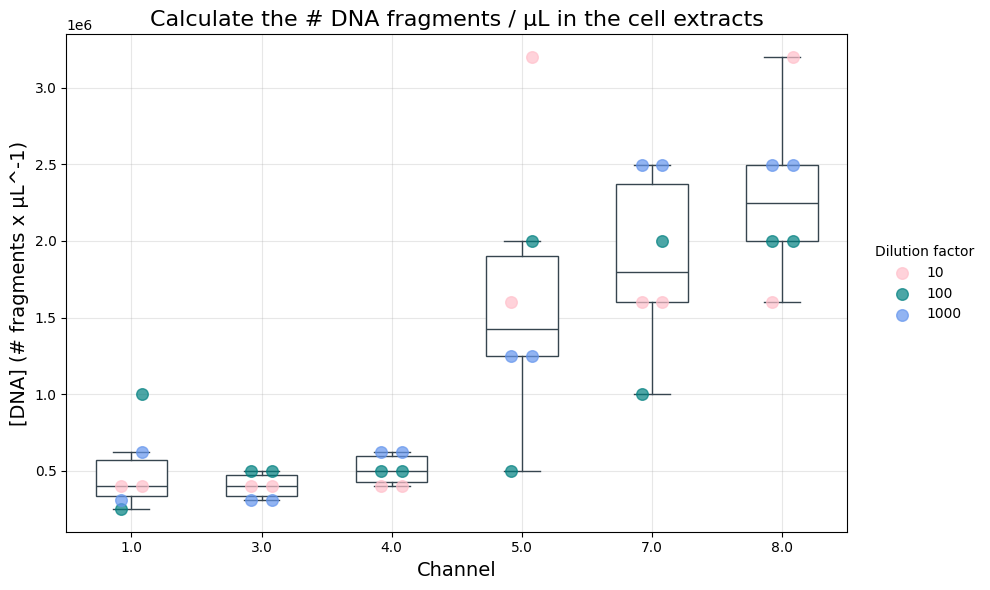

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plot_df = qpcr_sample.copy()

# keep channels in sorted order
channels = sorted(plot_df['channel'].unique())
channel_positions = np.arange(1, len(channels) + 1)

# data for boxplot
boxplot_data = [
    plot_df.loc[plot_df['channel'] == ch, 'dna_fragments_in_original_extract_per_ul'].values
    for ch in channels
]

# colours for dilution factors
color_map = {
    10: 'pink',
    100: 'teal',
    1000: 'cornflowerblue'
}

fig, ax = plt.subplots(figsize=(10, 6))

# boxplot
bp = ax.boxplot(
    boxplot_data,
    positions=channel_positions,
    widths=0.55,
    patch_artist=True,
    showfliers=False
)

for box in bp['boxes']:
    box.set(facecolor='white', edgecolor='#36454F', linewidth=1)

for whisker in bp['whiskers']:
    whisker.set(color='#36454F', linewidth=1)

for cap in bp['caps']:
    cap.set(color='#36454F', linewidth=1)

for median in bp['medians']:
    median.set(color='#36454F', linewidth=1)

# overlay points, coloured by dilution factor
for dilution_factor, color in color_map.items():
    subset = plot_df[plot_df['dilution_factor'] == dilution_factor]
    
    xs = []
    ys = []
    
    for ch in channels:
        y_vals = subset.loc[
            subset['channel'] == ch,
            'dna_fragments_in_original_extract_per_ul'
        ].values
        
        if len(y_vals) > 0:
            x_center = channel_positions[channels.index(ch)]
            # small horizontal jitter
            jitter = np.linspace(-0.08, 0.08, len(y_vals)) if len(y_vals) > 1 else np.array([0.0])
            xs.extend(x_center + jitter)
            ys.extend(y_vals)
    
    ax.scatter(xs, ys, color=color, s=70, alpha=0.7, label=str(dilution_factor), zorder=3)

ax.set_xticks(channel_positions)
ax.set_xticklabels([str(ch) for ch in channels])
ax.set_xlabel('Channel', fontsize=14)
ax.set_ylabel(r'[DNA] (# fragments x μL^-1)', fontsize=14)
ax.set_title('Calculate the # DNA fragments / μL in the cell extracts', fontsize=16)

ax.grid(True, alpha=0.3)
ax.legend(title='Dilution factor', bbox_to_anchor=(1.02, 0.5), loc='center left', frameon=False)

plt.tight_layout()
plt.savefig("boxplot_dnafragperul.pdf")
plt.show()

In [32]:
### Ploidy chromosomes per cell
#
# Chromoses per cell = (DNA fragments per μL in original extract) / (cell counts per μL in original extract)
#
# Given:
#   from casy: broken_cells_per_ml
#   from qpcr: dna_fragments_in_original_extract_per_ul
#
# broken cells = broken_cells_per_ml / 1000

In [33]:
ploidy_df = qpcr_sample.merge(
    data_casy_wide[['channel', 'broken_cells_per_ml']],
    on='channel',
    how='left'
)

ploidy_df['broken_cells_per_ul'] = ploidy_df['broken_cells_per_ml'] / 1000

ploidy_df['chromosomes_per_cell'] = (
    ploidy_df['dna_fragments_in_original_extract_per_ul']
    / ploidy_df['broken_cells_per_ul']
)

ploidy_df[
    [
        'sample_id', 'channel', 'replicate', 'dilution_factor',
        'dna_fragments_in_original_extract_per_ul',
        'broken_cells_per_ml', 'broken_cells_per_ul',
        'chromosomes_per_cell'
    ]
].sort_values(['channel', 'replicate', 'dilution_factor'])

plot_df.head()

,sample_id,channel,replicate,dilution_replicate,Ct,dilution_factor,sample_class,template_vol,final_vol,log10_dna_fragments_in_well_per_ul,dna_fragments_in_well_per_ul,dna_fragments_in_diluted_extract_per_ul,dna_fragments_in_original_extract_per_ul
0,200206_0_4,4.0,1,1.0,15,10,sample,5,20,4.000036,10000.826539,40003.306156,400033.061565
6,200206_0_4,4.0,1,2.0,18,100,sample,5,20,3.096810,1249.712426,4998.849706,499884.970551
12,200206_0_4,4.0,1,3.0,21,1000,sample,5,20,2.193584,156.165207,624.660829,624660.828794
18,200206_0_4,4.0,2,1.0,15,10,sample,5,20,4.000036,10000.826539,40003.306156,400033.061565
24,200206_0_4,4.0,2,2.0,18,100,sample,5,20,3.096810,1249.712426,4998.849706,499884.970551


In [34]:
### Ploidy summary by channel
ploidy_by_channel = (
    ploidy_df
    .groupby('channel', as_index=False)
    .agg(
        mean_chr_per_cell=('chromosomes_per_cell', 'mean'),
        sd_chr_per_cell=('chromosomes_per_cell', 'std'),
        n=('chromosomes_per_cell', 'size')
    )
)

ploidy_by_channel

,channel,mean_chr_per_cell,sd_chr_per_cell,n
0,1.0,3.036917,1.688780,6
1,3.0,1.645655,0.341901,6
2,4.0,1.438691,0.284975,6
3,5.0,3.355480,1.876789,6
4,7.0,4.821416,1.511033,6
5,8.0,5.596543,1.359599,6


In [35]:
### 95% CI for ploidy by channel
ploidy_by_channel['se'] = ploidy_by_channel['sd_chr_per_cell'] / np.sqrt(ploidy_by_channel['n'])
ploidy_by_channel['ci95'] = 1.96 * ploidy_by_channel['se']

In [36]:
data_design = pd.read_csv(f'{data_dir}/Design.csv', index_col=False)
data_design.head()

,channel,purpose,phosphate_mM
0,1,treatment,0.0115
1,3,treatment,0.0115
2,4,treatment,0.0115
3,5,control,0.2300
4,7,control,0.2300


In [37]:
### Ploidy by condition

ploidy_by_condition = ploidy_by_channel.merge(
    data_design,
    on='channel',
    how='left'
)

ploidy_by_condition

,channel,mean_chr_per_cell,sd_chr_per_cell,n,se,ci95,purpose,phosphate_mM
0,1.0,3.036917,1.688780,6,0.689441,1.351305,treatment,0.0115
1,3.0,1.645655,0.341901,6,0.139580,0.273578,treatment,0.0115
2,4.0,1.438691,0.284975,6,0.116341,0.228027,treatment,0.0115
3,5.0,3.355480,1.876789,6,0.766196,1.501744,control,0.2300
4,7.0,4.821416,1.511033,6,0.616877,1.209078,control,0.2300
5,8.0,5.596543,1.359599,6,0.555054,1.087906,control,0.2300


In [38]:
ploidy_by_condition_summary = (
    ploidy_by_condition
    .groupby(['purpose', 'phosphate_mM'], as_index=False)
    .agg(
        mean_chr_per_cell=('mean_chr_per_cell', 'mean'),
        sd_chr_per_cell=('mean_chr_per_cell', 'std'),
        n=('mean_chr_per_cell', 'size')
    )
)

ploidy_by_condition_summary['se'] = ploidy_by_condition_summary['sd_chr_per_cell'] / np.sqrt(ploidy_by_condition_summary['n'])
ploidy_by_condition_summary['ci95'] = 1.96 * ploidy_by_condition_summary['se']

ploidy_by_condition_summary

,purpose,phosphate_mM,mean_chr_per_cell,sd_chr_per_cell,n,se,ci95
0,control,0.2300,4.591146,1.138138,3,0.657104,1.287925
1,treatment,0.0115,2.040421,0.869173,3,0.501817,0.983562


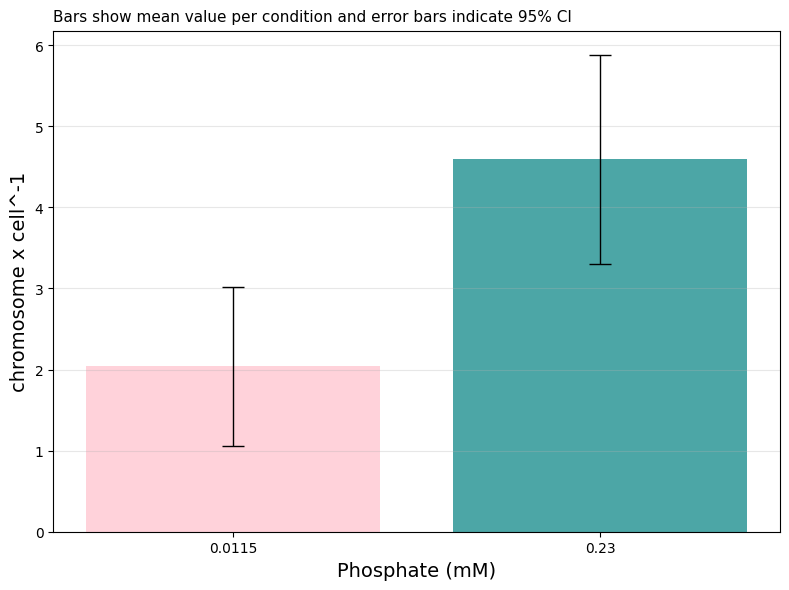

In [39]:
plot_df = ploidy_by_condition_summary.sort_values('phosphate_mM').copy()

x = plot_df['phosphate_mM'].astype(str)
y = plot_df['mean_chr_per_cell']
yerr = plot_df['ci95']

colors = ['pink', 'teal']

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(x, y, color=colors[:len(plot_df)], alpha=0.7)
ax.errorbar(
    x, y, yerr=yerr,
    fmt='none',
    ecolor='black',
    elinewidth=1,
    capsize=8
)

ax.text(
    0.0, 1.02,
    'Bars show mean value per condition and error bars indicate 95% CI',
    transform=ax.transAxes,
    fontsize=11
)

ax.set_xlabel('Phosphate (mM)', fontsize=14)
ax.set_ylabel(r'chromosome x cell^-1', fontsize=14)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("chromosome_percell.pdf")
plt.show()